# Forecast example
This notebook provides a basic example of forecasting using the PyOnlineForecast package.

The notebook covers
- Working with data in "forecast matrix" format
- Basic prediction using ```WLS``
- Recursive ridge regression and prediction using ``ForecastModel``
- Making ensembles for multi-horizon forecasting using ``ForecastEnsemble``
- Suggestion for hyper parameter optimization

We will use an artificial dataset from the ``datasets`` module.

In [121]:
from py_online_forecast import *
from py_online_forecast.datasets import sample_data
from py_online_forecast.forecast_tools import Subset

## Data & forecast matrices
The sample data is a pandas dataframe obeying the "forecast matrix" format. This means that the columns are a two level ``MultiIndex`` and that the (row) index is evenly spaced and monotonically increasing. We start by subsetting the data using the ``fc`` accessor, purpose built for working with data in this format.

In [123]:
data = sample_data.fc.subset(horizons=(0, 1, 2, 4)).iloc[:200]
data.head()

Variable                energy      Taobs         Ta                      
Horizon                      0          0          1          2          4
2130-01-01 00:00:00  51.531885  15.668848  14.732529  18.112065  18.771499
2130-01-01 01:00:00  50.988901  16.327964  18.274593  18.991357  18.759832
2130-01-01 02:00:00  50.479686  18.319822  15.477482  22.260192  19.841512
2130-01-01 03:00:00  50.420587  20.230697  15.111263  20.589555  19.198036
2130-01-01 04:00:00  56.704199  19.268107  17.443227  20.205426  18.872228

The forecast matrix prescribes that the columns should contain variable names and integer horizons. This way, the $i´th$ row contains all data made available at the corresponding time, and forecasts are made for row $i+horizon$.

The ``fc`` accessor defines convenience methods for working with such data,
- ``subset`` subsets data by variable names and horizon
- ``lag`` lags data according to the forecast horizon to align data with the time forecasts are made for
- ``assert_format`` asserts whether the dataframe conforms to the forecast matrix format
- ``convert`` converts nearly compatible dataframes to the format

In [129]:
# Subset data
subset_data  = data.fc.subset("energy", "Ta", horizons = (0, 1, 2))

# Lag data
lagged_data = subset_data.fc.lag()

# Assert format
subset_data.fc.assert_format()

# Convert to forecast format
converted_data = lagged_data.fc.convert() 

converted_data.head()


Variable                energy         Ta           
Horizon                      0          1          2
2130-01-01 00:00:00  51.531885        NaN        NaN
2130-01-01 01:00:00  50.988901  14.732529        NaN
2130-01-01 02:00:00  50.479686  18.274593  18.112065
2130-01-01 03:00:00  50.420587  15.477482  18.991357
2130-01-01 04:00:00  56.704199  15.111263  22.260192

## Forecasting
Our goal is now to model the ``energy`` variable based on temperature observations ``Taobs`` and forecasted temperatures ``Ta``. First we define model features,

In [ ]:
# Target variable
energy = DEFAULT_SOURCE[["energy"]]

# Exogenous variables
taobs = DEFAULT_SOURCE[["Taobs"]]
ta = Subset(DEFAULT_SOURCE, "Ta", horizons=(1,))
const = One()

# Low-pass filter
lp_Taobs = LowPass(taobs, alpha=0.7)
lp_Ta = LowPass(ta, alpha=0.8)

# Construct the design matrix
X = DesignMatrix(const, lp_Taobs, lp_Ta)


We can then create a simple weighted least squares model using the ``WLS`` class,

In [150]:
# Set a prediction model using weighted least squares (WLS)
pred = WLS(X, energy, horizon=1)

# Make predictions
result = pred(data) # Produces a dict with a key "mean"
result["mean"][:5] # Print the first 5 predictions


array([[50.53197728],
       [50.84301371],
       [50.21675878],
       [49.23751956],
       [49.11157806]])

Note, the output does not use the forecast matrix format, unless we set it using the ``ForecastFormat``,

In [151]:
from py_online_forecast.forecast_tools import ForecastFormat
pred.set_format(ForecastFormat)

result = pred(data) # Produces a dict with keys "mean"
result["mean"].head() # Output is now a DataFrame

Variable,energy
Horizon,1
2130-01-01 00:00:00,50.531977
2130-01-01 01:00:00,50.843014
2130-01-01 02:00:00,50.216759
2130-01-01 03:00:00,49.237520
2130-01-01 04:00:00,49.111578


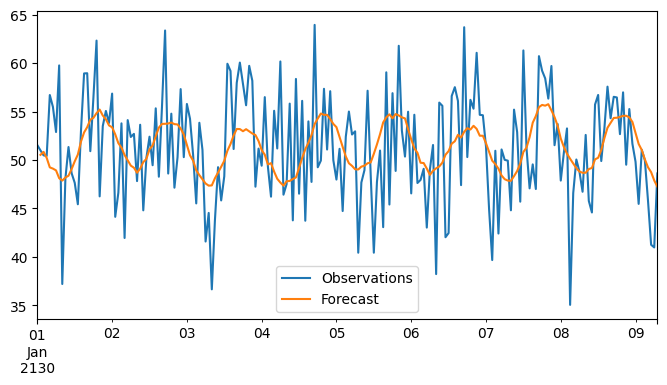

In [152]:
import matplotlib.pyplot as plt

# Plot the predicted mean versus the observations
ax = data.plot(y="energy", figsize = (8, 4))
result["mean"].fc.lag().plot(ax=ax)  # Shift predictions 1 hour ahead
plt.legend(["Observations", "Forecast"])
plt.show()

For online forecasting, the ``RRR`` transformation or the ``ForecastModel`` wrapper are better suited, as they use recursive updating schemes. The ``ForecastModel`` is especially convenient, as it automatically formas a ``DesignMatrix`` from a tuple of input features and uses the ``ForecastFormat``. It also exposes a ``fit`` method, which resets the state of the ``ForecastModel`` transformation and then calls it on the data.

In [157]:
# Create tuple of features
X = (const, lp_Taobs, lp_Ta)

# Create the model
model = ForecastModel(X, energy, 1, track_memory=True, init_K=0.00001)

# Fit the model using the "fit" method
result = model.fit(data, mem=1)

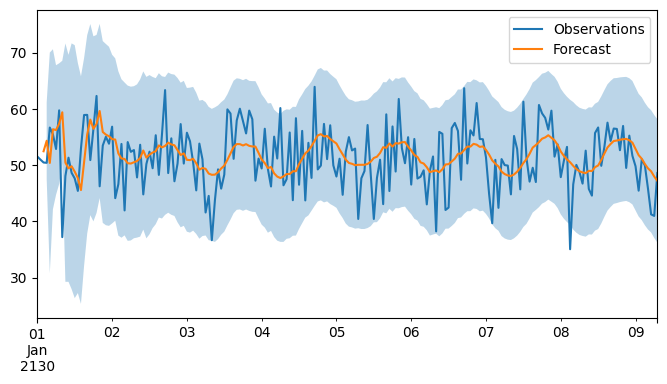

In [176]:
import numpy as np

# Plot the predictions
ax = data.plot(y="energy", figsize = (8, 4))

# Plot the mean prediction
lagged_mean = result["mean"].fc.lag().iloc[:, 0]  # Shift predictions 1 hour ahead
lagged_mean.plot(ax=ax)

# Plot prediction interval
lagged_cov = result["cov"].fc.lag().iloc[:, 0]  # Shift covariance 1 hour ahead
lower = lagged_mean.sub(2*np.sqrt(lagged_cov))
upper = lagged_mean.add(2*np.sqrt(lagged_cov))
ax.fill_between(data.index, lower, upper, alpha = 0.3)


plt.legend(["Observations", "Forecast"])
plt.show()


Multivariate targets are supported with a similar setup,

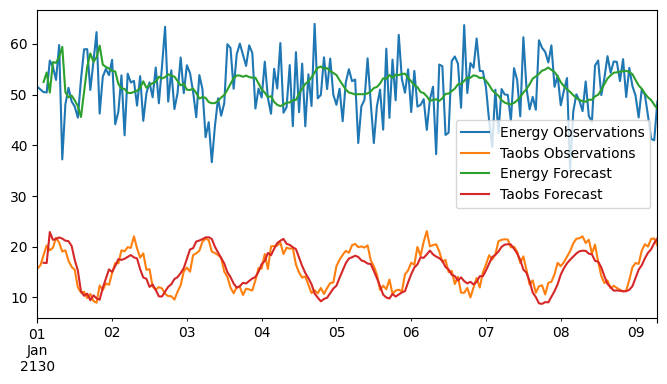

In [181]:
target = DEFAULT_SOURCE[["energy", "Taobs"]]
model_multi = ForecastModel(X, target, horizon=1, track_memory=True, init_K=0.00001)
result_multi = model_multi.fit(data, mem=1)

# Plot the predicted mean versus the observations
ax = data.plot(y="energy", figsize = (8, 4))
data.plot(y="Taobs", ax=ax)
result_multi["mean"].fc.lag().plot(ax=ax)
plt.legend(["Energy Observations", "Taobs Observations", "Energy Forecast", "Taobs Forecast"])
plt.show()

Online updates can be emulated by passing data points one at a time. Most transforms tacitly assume that the first axis of inputs correspond to observations. For single samples, we should therefore pass a dataframe with a single row as input.

In [ ]:
import pandas as pd

# Subset data
subsets = [data.iloc[[i]] for i in range(len(data))]

# Reset model for proper comparison
model.reset_state()
predictions = []

# Update model with each data subset
for s in subsets:
    p = model.update(s, mem=1)["mean"]
    predictions.append(p)

predictions = pd.concat(predictions)

# Compare predictions with the previous results
print(
    np.allclose(result["mean"].to_numpy()[1:], predictions.to_numpy()[1:])
)  # Should be True


True


When forecasting multiple horizons, several approaches are possible. One approach is the create a separate model for each horizon. This is supported by the ``ForecastEnsemble`` transformation, which instantiates ``ForecastModel`` for each horizon it is given. We begin by making a new model for the second horizon,

In [ ]:
# Create a new model for 2-hour ahead forecasts
ta2 = Subset(DEFAULT_SOURCE, "Ta", horizons=(2,))  # Use all available forecasts of Ta

# Low-pass filter for the new model
lp_Ta2 = LowPass(ta2, alpha=0.8)

X2 = (const, lp_Taobs, lp_Ta2)

# We then make a prediction for the 2-hour ahead forecast
model_2h = ForecastModel(X2, energy, horizon=2, track_memory=True, init_K=0.00001)

# Note, we can still run the prediction as a standalone object
ref_1h = model.fit(data, mem=1)
ref_2h = model_2h.fit(data, mem=1)

With this setup, some transformations are evaluated multiple times; first when ``model`` is called, then when ``model_2h`` is called. To avoid this, we can use ``Combine`` to evaluate both in one call,

In [191]:
models = Combine(model, model_2h)

# Apply the combined model
result = models(data, mem=1)

# Results are returned in a dict indexed by the individual transforms (models),
result_model_1h = result[model]
result_model_2h = result[model_2h]

In [192]:
result_model_1h["mean"].head()

Variable,energy
Horizon,1
2130-01-01 00:00:00,NaN
2130-01-01 01:00:00,52.477670
2130-01-01 02:00:00,54.352502
2130-01-01 03:00:00,50.405863
2130-01-01 04:00:00,56.399926


In [193]:
result_model_2h["mean"].head()

Variable,energy
Horizon,2
2130-01-01 00:00:00,NaN
2130-01-01 01:00:00,NaN
2130-01-01 02:00:00,53.309106
2130-01-01 03:00:00,43.747420
2130-01-01 04:00:00,19.704705


Finally, we can achieve this more easily using the ``ForecastEnsemble`` class.

In [188]:
# First, get all forecasts of Ta
ta_all = DEFAULT_SOURCE[["Ta"]]

# Apply low-pass filters to all forecasts of Ta.
lp_Ta_all = LowPass(ta_all, alpha=0.8)
Xall = (const, lp_Taobs, lp_Ta_all)
horizon_models = ForecastEnsemble(
    Xall,
    energy,
    horizons=(1, 2),
    input_horizons="auto",
    track_memory=True,
    init_K=0.00001,
)

# Then fit the ensemble as normal
horizon_result = horizon_models.fit(data, mem=1)
horizon_result["mean"].head()

Variable                energy           
Horizon                      1          2
2130-01-01 00:00:00        NaN        NaN
2130-01-01 01:00:00  52.477670        NaN
2130-01-01 02:00:00  54.352502  53.309106
2130-01-01 03:00:00  50.405863  43.747420
2130-01-01 04:00:00  56.399926  19.704705

In [195]:
# Ensembles can also be updated in an online fashion
horizon_models.reset_state()
predictions = []
for s in subsets:
    p = horizon_models.update(s, mem=1)["mean"]
    predictions.append(p)

predictions = pd.concat(predictions, axis=0)

# Compare (except two first rows, as they contain NaNs)
print(
    np.allclose(horizon_result["mean"].to_numpy()[2:], predictions.to_numpy()[2:])
)  # Should be True

True


## Hyperparameter optimization
Hyperparameters are not optimized for in the forecast models. Instead we may manually change parameters and define an outer loop optimization procedure. As an example, consider a slow trend in the data

In [ ]:
# For a non-trivial case, we add a slow trend in the data
trend_data = data.copy()
trend_data[("energy", 0)] += 0.1 * np.arange(len(trend_data))

Then we can use the ``set_score_mode`` of the model to compute a "score" field in the output. The ``set_score_mode`` is special to ``Prediction`` transformations, e.g. ``ForecastModel`` and ``RRR``. The method asks the prediction model to also call a score function, which in this case computes the RMSE.

In [197]:
from scipy.optimize import minimize

# Set score mode to true
model.set_score_mode()

# Define objective in transformation parameters
def obj(x):
    alpha, mem = x
    lp_Taobs.alpha = alpha
    lp_Ta.alpha = alpha
    return model.fit(trend_data, mem=mem)["score"]

# Run the minimization
res = minimize(obj, x0=[0.5, 0.5], bounds=[(0, 1), (0, 1)], method="Nelder-Mead")
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.700395088827669
             x: [ 3.377e-01  9.324e-01]
           nit: 63
          nfev: 120
 final_simplex: (array([[ 3.377e-01,  9.324e-01],
                       [ 3.378e-01,  9.324e-01],
                       [ 3.377e-01,  9.324e-01]]), array([ 5.700e+00,  5.700e+00,  5.700e+00]))